In [1]:
import keras
import tensorflow
from tensorflow.keras.datasets import mnist

In [3]:
dataset = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 33s 3us/step


In [4]:
(x_train, y_train), (x_test,y_test) = mnist.load_data()

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_test.shape

(10000, 28, 28)

In [7]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [8]:
x_train = x_train / 255
x_test = x_test / 255

In [9]:
x_train.shape

(60000, 28, 28)

In [10]:
y_train = tensorflow.keras.utils.to_categorical(y_train, num_classes = 10)

In [11]:
y_test = tensorflow.keras.utils.to_categorical(y_test, num_classes = 10)

In [12]:
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

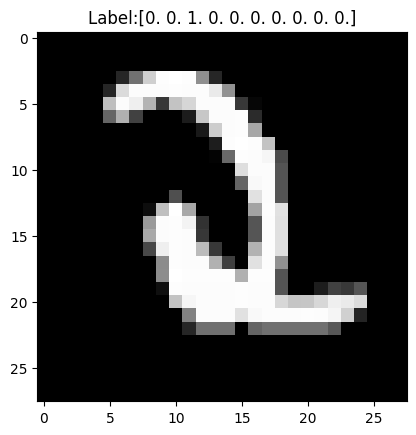

In [13]:
import matplotlib.pyplot as plt
plt.imshow(x_train[400], cmap = 'grey')
plt.title(f'Label:{y_train[400]}')
plt.show()

In [14]:
import tensorflow.keras as tf

In [15]:
cnn = tf.models.Sequential()
cnn.add(tf.layers.Conv2D(8, kernel_size = (3,3), activation = 'relu', input_shape=[28, 28, 1]))
cnn.add(tf.layers.MaxPool2D(pool_size = (2,2)))
cnn.add(tf.layers.Conv2D(16, kernel_size = (3,3), activation = 'relu'))
cnn.add(tf.layers.Conv2D(4, kernel_size = (3,3), activation = 'relu'))
cnn.add(tf.layers.MaxPool2D(pool_size = (2,2)))
cnn.add(tf.layers.Flatten())
cnn.add(tf.layers.Dense(units = 16, activation = 'relu'))
cnn.add(tf.layers.Dense(units = 10, activation = 'softmax'))

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 8)           │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 9, 9, 4)             │             580 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 4)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,038 (11.87 KB)

 Trainable params: 3,038 (11.87 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
cnn.compile(loss= tensorflow.keras.losses.categorical_crossentropy, optimizer = tensorflow.keras.optimizers.Adam(), metrics = ['Accuracy'])

In [18]:
cnn.fit(x_train, y_train, batch_size = 32, epochs = 2)

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - Accuracy: 0.8712 - loss: 0.4133
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - Accuracy: 0.9468 - loss: 0.1740


In [19]:
pred = cnn.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [20]:
cnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - Accuracy: 0.9578 - loss: 0.1373


[0.13730856776237488, 0.9577999711036682]

In [21]:
pred_class = pred.argmax(axis=1)
pred_class

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))